## Import thư viện và khởi tạo OCR Engine

In [1]:
import sys
sys.path.insert(0, '..')

import os
import json
import glob
import matplotlib.pyplot as plt
from PIL import Image

from src.ocr.ocr_processor import PaddleOCRProcessor

# Khởi tạo OCR processor
ocr_processor = PaddleOCRProcessor(
    use_doc_orientation_classify=False,
    use_doc_unwarping=False,
    use_textline_orientation=False
)

c:\Users\Thach\miniconda3\envs\project\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `DISABLE_MODEL_SOURCE_CHECK` to `True`.


Đang khởi tạo PaddleOCR engine...


c:\Users\Thach\miniconda3\envs\project\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-OCRv5_server_det', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_det`.
Creating model: ('PP-OCRv5_server_rec', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\Thach\.paddlex\official_models\PP-OCRv5_server_rec`.


-> PaddleOCR đã sẵn sàng!


## Cấu hình đường dẫn

In [2]:
from src.utils.constant import *
from src.ocr.layout import *

Input folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_Images
Output folder: d:\Thach\HUST\Project_1\VQA\code\dataset\DocVQA_OCR


## Chọn 1 ảnh mẫu

['../dataset/DocVQA_Images\\train\\1084.png']
Chạy OCR với Layout Analysis...

KẾT QUẢ LAYOUT ANALYSIS
Số lines: 47
Số blocks: 17
Số regions: 13

Regions phát hiện:
--------------------------------------------------------------------------------

1. Type: TEXT | Score: 1.000
   - Avg line length: 95.5
   - Spacing uniformity: 1.00

2. Type: TEXT | Score: 1.000
   - Avg line length: 81.3
   - Spacing uniformity: 0.97

3. Type: TEXT | Score: 1.000
   - Avg line length: 82.8
   - Spacing uniformity: 0.99

4. Type: TEXT | Score: 1.000
   - Avg line length: 90.0
   - Spacing uniformity: 1.00

5. Type: TEXT | Score: 0.720
   - Avg line length: 44.0
   - Spacing uniformity: 1.00

6. Type: TEXT | Score: 1.000
   - Avg line length: 76.8
   - Spacing uniformity: 0.98

7. Type: TEXT | Score: 1.000
   - Avg line length: 92.7
   - Spacing uniformity: 1.00

8. Type: TEXT | Score: 0.710
   - Avg line length: 43.2
   - Spacing uniformity: 0.99

9. Type: TEXT | Score: 0.835
   - Avg line length: 67.8
 

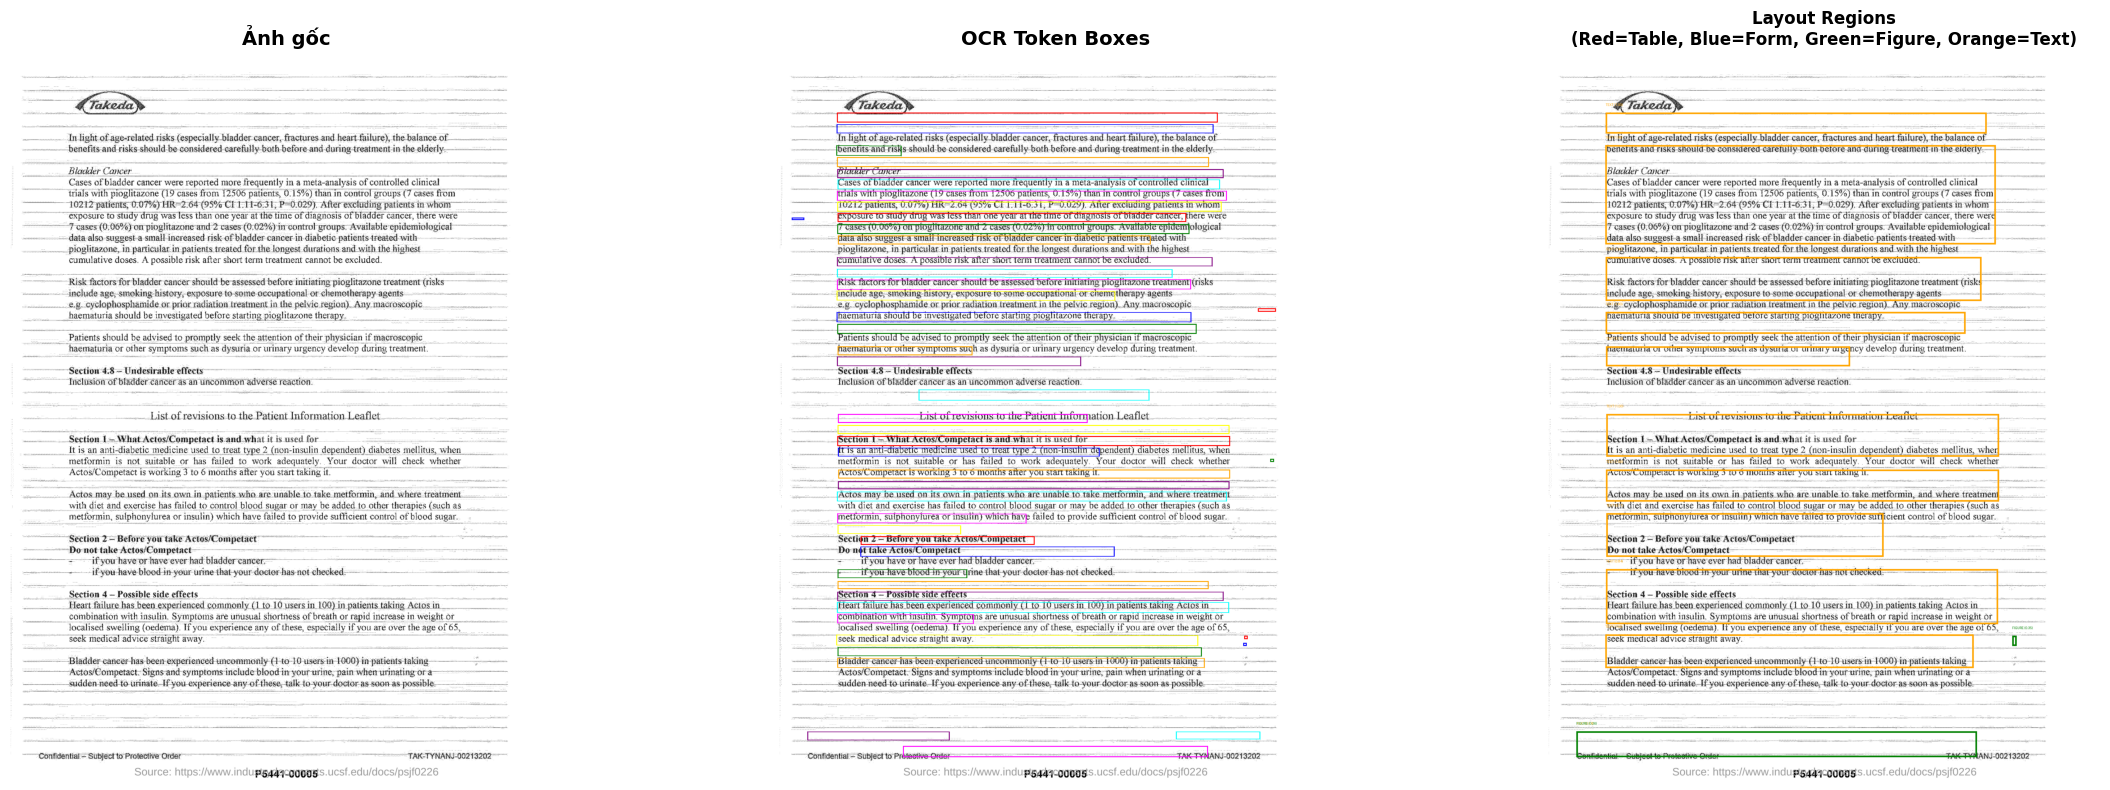


LEGEND - Region Colors:
  🔴 RED    = Table (bảng)
  🔵 BLUE   = Form (key:value)
  🟢 GREEN  = Figure (chart/plot)
  🟠 ORANGE = Text (đoạn văn)
  🟣 PURPLE = Layout (multi-column/heading)

TEXT CONTENT THEO TỪNG REGION

────────────────────────────────────────────────────────────────────────────────
📋 FIGURE REGIONS (2 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[FIGURE #1] Score: 0.350
────────────────────────────────────────
 1. r
 2. F

[FIGURE #2] Score: 0.255
────────────────────────────────────────
 1. Confidential-Subject to ProtectiveOrder
 2. Source:https://www.industrydqcoments.ucsf.edu/docs/psjf0226

────────────────────────────────────────────────────────────────────────────────
📋 TEXT REGIONS (11 phát hiện)
────────────────────────────────────────────────────────────────────────────────

[TEXT #1] Score: 1.000
────────────────────────────────────────
 1. In light ofage-related risks（especially bladder cancerfractures and heart

In [3]:
# Tìm 1 ảnh mẫu
import random

sample_image = None
idx = random.randint(0, 1000)
if sample_image is None:
    for subset in SUBSETS:
        subset_folder = os.path.join(IMAGES_FOLDER, subset)
        if os.path.exists(subset_folder):
            images = glob.glob(os.path.join(subset_folder, "*.png"))[idx:idx+1]
            print(images)
            if images:
                sample_image = images[0]
                break
else:
    images = os.path.join(IMAGES_FOLDER, 'train', f'{sample_image}.png')
    
group(sample_image, ocr_processor)

## So sánh ảnh trước và sau preprocess

In [4]:
# preprocess(sample_image, ocr_processor)

---
## Document Layout Analysis

Phân tích cấu trúc document sau khi OCR:
- **Stage I**: Group token → line → block
- **Stage II**: Detect regions (table, form, figure, text, layout)

## Visualize Stage I Groups

Hiển thị các bước grouping ở Stage I:
- **Token**: Các bounding box từ OCR
- **Line**: Gộp tokens thành lines
- **Block**: Gộp lines thành blocks

Chạy OCR với Layout Analysis...


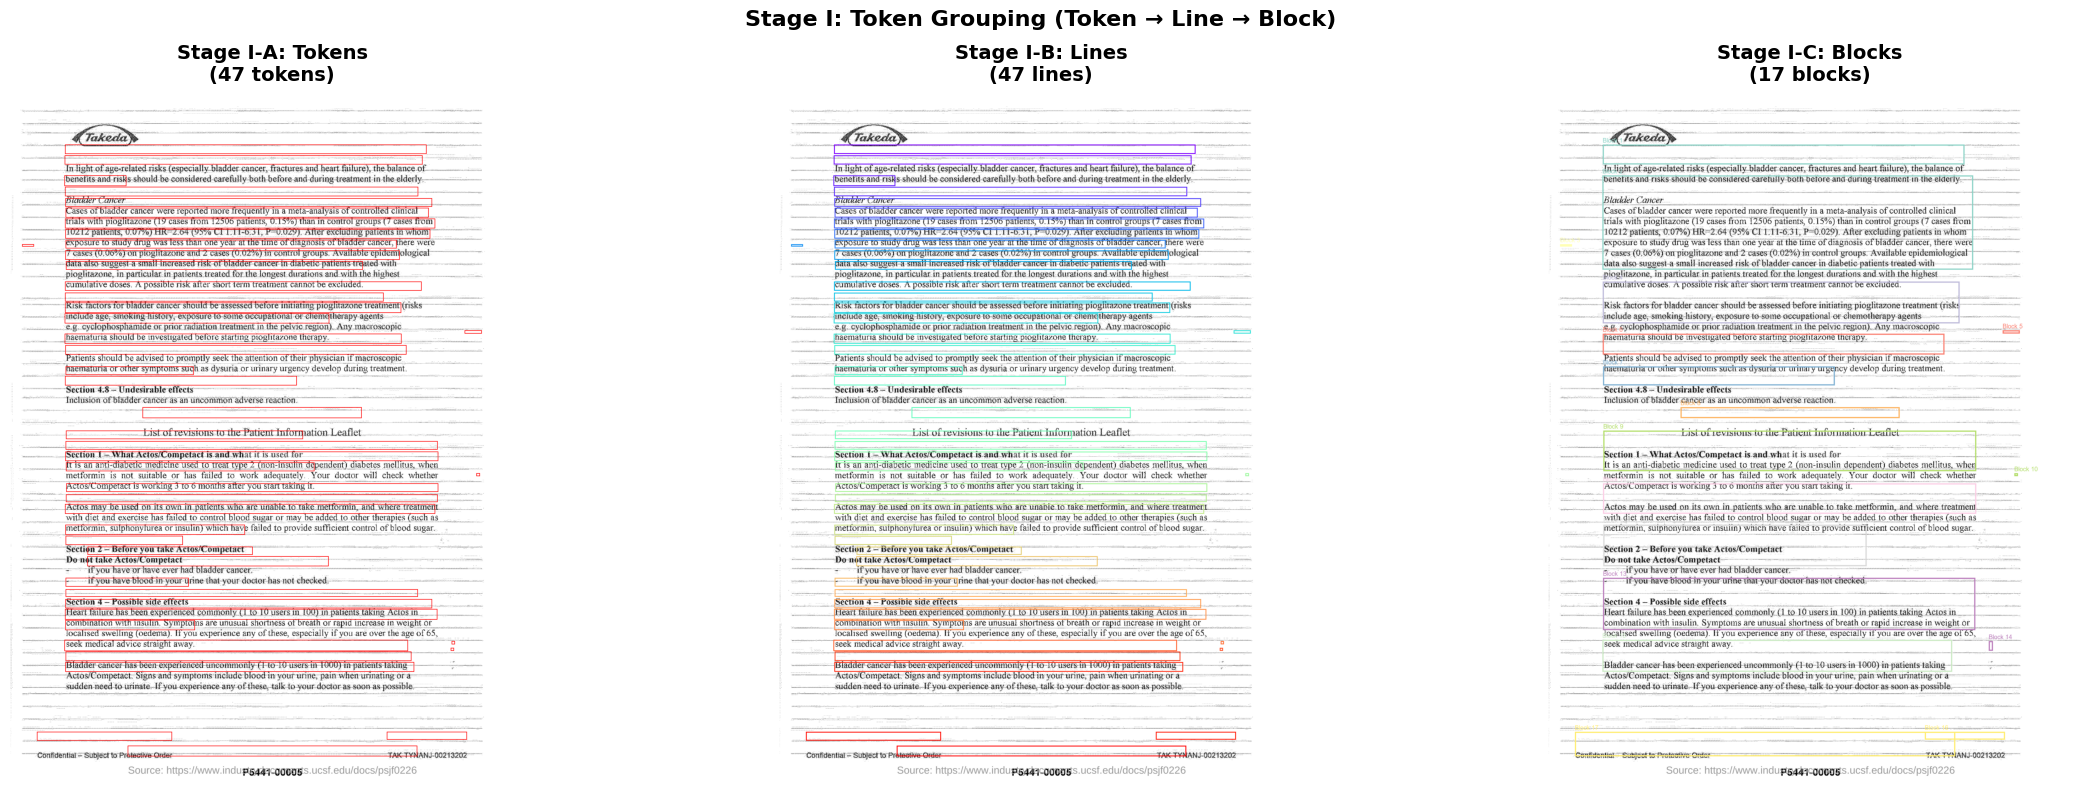


STAGE I - TOKEN GROUPING STATISTICS
Tokens: 47
Lines:  47
Blocks: 17



{'text': 'In light ofage-related risks（especially bladder cancerfractures and heart failure)the balance of benefits andrisks should be considered carefully both beforeand during treatment in the elderly Bladder Cancer Cases ofbladder cancer were reported more frequently in a meta-analysis of controlled clinical trials with pioglitazone（19 cases from12506 patients,0.15%)thanincontrol groups（7casesfrom 10212patients.0.07%)HR=2.64 （95%C11.11-6.31,P=0.029).Afterexcludingpatientsinwhom exposure to study drug was less than one year at the time of diagnosis of bladder cancer, there were 7 cases (0.06%)onpioglitazone and 2 cases(0.02%)in control groups.Available epidemiological data also suggest a small inereased risk ofbladder cancer in diabetic patients treated with 2 pioglitazone,in particular in patients treated for thelongest durations and with the highest cumulative doses.A possible risk after short term treatment cannot be excluded. Risk factors forbladder cancer should be assessed befo

In [5]:
visualize_stage1_groups(sample_image, ocr_processor)

In [6]:
# group(sample_image, ocr_processor)

## Xử lý OCR hàng loạt cho toàn bộ Dataset

In [7]:
# # Xử lý OCR cho 500 ảnh đầu tiên của mỗi subset với PREPROCESSING
# all_stats = ocr_processor.process_docvqa_images(
#     images_folder=IMAGES_FOLDER,
#     output_folder=OUTPUT_FOLDER,
#     subsets=SUBSETS,
#     max_images_per_subset=500,  # Giới hạn 500 ảnh mỗi subset
#     use_preprocessing=True,      # BẬT preprocessing
#     max_size=2500                # Resize max 2500px
# )

## Xem kết quả đã xử lý

In [8]:
# # Đếm số file JSON đã tạo
# print("="*60)
# print("THỐNG KÊ KẾT QUẢ OCR")
# print("="*60)

# for subset in SUBSETS:
#     subset_output = os.path.join(OUTPUT_FOLDER, subset)
#     if os.path.exists(subset_output):
#         json_files = glob.glob(os.path.join(subset_output, "*.json"))
#         print(f"  {subset:15}: {len(json_files):,} files")
#     else:
#         print(f"  {subset:15}: 0 files (chưa xử lý)")

# # Đếm tổng
# total_json = len(glob.glob(os.path.join(OUTPUT_FOLDER, "**/*.json"), recursive=True))
# print("="*60)
# print(f"  {'TỔNG':15}: {total_json:,} files")